# Connect Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive connected!')

Mounted at /content/drive
Google Drive connected!


# Check Dataset Classes and Image Count

In [2]:
import os

DATASET_PATH = '/content/drive/MyDrive/joAccess_dataset/dataset'

print('Dataset Summary:')
print('=' * 40)
total = 0
classes = []
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_path):
        count = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))])
        print(f'  {cls:<25} {count} images')
        total += count
        classes.append(cls)
print('=' * 40)
print(f'  Total images : {total}')
print(f'  Total classes: {len(classes)}')
print(f'  Classes      : {classes}')

Dataset Summary:
  accessible_parking        1515 images
  accessible_restroom       1226 images
  braille_signage           1403 images
  elevator                  1500 images
  wheelchair_ramp           1530 images
  Total images : 7174
  Total classes: 5
  Classes      : ['accessible_parking', 'accessible_restroom', 'braille_signage', 'elevator', 'wheelchair_ramp']


# Import Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import copy
import time

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('No GPU found - training will be slow!')

Using device: cuda
GPU: Tesla T4


# Define Custom Dataset that Skips Corrupted Images

In [4]:
from torchvision.datasets import ImageFolder
from PIL import Image

class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except Exception:
            # Skip corrupted image and get next one
            return self.__getitem__((index + 1) % len(self))

print('SafeImageFolder defined!')

SafeImageFolder defined!


# Remove Corrupted Images from Dataset

In [5]:
import os
from PIL import Image

corrupted = []

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_path):
        continue
    for img_file in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_file)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except Exception:
            corrupted.append(img_path)
            os.remove(img_path)

print(f'Corrupted images removed: {len(corrupted)}')
print('Dataset is clean now!')

Corrupted images removed: 0
Dataset is clean now!


# Define Preprocessing and Augmentation Transforms

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print('Transforms defined!')

Transforms defined!


# Load Dataset and Split into Train, Validation and Test

In [7]:
full_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transforms)
class_names = full_dataset.classes
print(f'Classes: {class_names}')
print(f'Total  : {len(full_dataset)} images')

train_size = int(0.70 * len(full_dataset))
val_size   = int(0.15 * len(full_dataset))
test_size  = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

val_dataset.dataset  = copy.deepcopy(full_dataset)
val_dataset.dataset.transform  = val_transforms
test_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset.transform = val_transforms

print(f'Train : {train_size} images')
print(f'Val   : {val_size} images')
print(f'Test  : {test_size} images')

Classes: ['accessible_parking', 'accessible_restroom', 'braille_signage', 'elevator', 'wheelchair_ramp']
Total  : 7174 images
Train : 5021 images
Val   : 1076 images
Test  : 1077 images


# Create DataLoaders for Train, Validation and Test

In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print('Batch size : 32')
print('DataLoaders ready!')

Batch size : 32
DataLoaders ready!


# Build EfficientNet-B0 Model with 5 Output Classes

In [9]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

# Load pretrained model
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace last layer with 5 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 5)
)

# Move model to GPU
model = model.to(device)

print('Model built successfully!')
print(f'Output classes: {class_names}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 104MB/s]


Model built successfully!
Output classes: ['accessible_parking', 'accessible_restroom', 'braille_signage', 'elevator', 'wheelchair_ramp']


# Define Loss Function and Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print('Loss     : CrossEntropyLoss')
print('Optimizer: Adam (lr=0.001)')
print('Scheduler: StepLR')

Loss     : CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: StepLR


# Train the Model

In [ ]:
NUM_EPOCHS = 10
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print('Starting Training...')
print('=' * 50)

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # Training phase
    model.train()
    train_loss, train_correct = 0.0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Validation phase
    model.eval()
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    # Calculate metrics
    train_loss = train_loss / len(train_dataset)
    val_loss   = val_loss   / len(val_dataset)
    train_acc  = train_correct / len(train_dataset)
    val_acc    = val_correct   / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    scheduler.step()

    elapsed = time.time() - start
    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} Train Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

print('=' * 50)
print(f'Best Validation Accuracy: {best_acc:.4f}')

# Load best model
model.load_state_dict(best_model_wts)
print('Best model loaded!')

Starting Training...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/10] Train Loss: 0.9486 Train Acc: 0.6744 | Val Loss: 0.6388 Val Acc: 0.7900 | Time: 180.5s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/10] Train Loss: 0.6819 Train Acc: 0.7672 | Val Loss: 0.5413 Val Acc: 0.8169 | Time: 152.2s


...

Epoch [08/10] Train Loss: 0.5927 Train Acc: 0.7923 | Val Loss: 0.5052 Val Acc: 0.8262 | Time: 154.1s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [09/10] Train Loss: 0.5841 Train Acc: 0.7949 | Val Loss: 0.5106 Val Acc: 0.8234 | Time: 153.8s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] Train Loss: 0.5846 Train Acc: 0.7929 | Val Loss: 0.5115 Val Acc: 0.8262 | Time: 154.8s
Best Validation Accuracy: 0.8281
Best model loaded!


# Evaluate Model on Test Set

In [ ]:
model.eval()
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / len(test_dataset)
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=class_names))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 0.8384 (83.84%)
                     precision    recall  f1-score   support

 accessible_parking       0.86      0.88      0.87       216
accessible_restroom       0.84      0.72      0.77       183
    braille_signage       0.80      0.84      0.82       222
           elevator       0.86      0.89      0.88       244
    wheelchair_ramp       0.83      0.84      0.84       212

           accuracy                           0.84      1077
          macro avg       0.84      0.83      0.83      1077
       weighted avg       0.84      0.84      0.84      1077



In [ ]:
import itertools

# A group of hyperparameters to try
param_grid = {
    'lr':       [0.001, 0.0001, 0.00001],
    'dropout':  [0.3, 0.5],
    'unfreeze': [0, 10, 20],
}

results = []

for lr, dropout, unfreeze in itertools.product(
    param_grid['lr'],
    param_grid['dropout'],
    param_grid['unfreeze']
):
    print(f'\nTrying: lr={lr}, dropout={dropout}, unfreeze={unfreeze}')
    print('-' * 50)

    # Build model
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    m = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

    # Freeze all layers
    for param in m.parameters():
        param.requires_grad = False

    # Unfreeze last N layers
    if unfreeze > 0:
        layers = list(m.features.children())
        for layer in layers[-unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Replace classifier
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(m.classifier[1].in_features, 5)
    )
    m = m.to(device)

    # Optimizer
    opt = optim.Adam(
        filter(lambda p: p.requires_grad, m.parameters()),
        lr=lr
    )
    sched = optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

    # Train for 5 epochs only (quick test)
    best_val = 0.0
    for epoch in range(5):
        m.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            opt.zero_grad()
            out = m(inputs)
            loss = criterion(out, labels)
            loss.backward()
            opt.step()

        m.eval()
        val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                out = m(inputs)
                val_correct += (out.argmax(1) == labels).sum().item()
        val_acc = val_correct / len(val_dataset)
        if val_acc > best_val:
            best_val = val_acc
        sched.step()

    print(f'  Best Val Acc: {best_val:.4f} ({best_val*100:.2f}%)')
    results.append({
        'lr': lr,
        'dropout': dropout,
        'unfreeze': unfreeze,
        'val_acc': best_val
    })

# Print summary
print('\n' + '=' * 60)
print('GRID SEARCH RESULTS:')
print('=' * 60)
results.sort(key=lambda x: x['val_acc'], reverse=True)
for r in results:
    print(f"lr={r['lr']:<8} dropout={r['dropout']} unfreeze={r['unfreeze']:<3} → Val Acc: {r['val_acc']*100:.2f}%")

print('\n' + '=' * 60)
best = results[0]
print(f"Best Params: lr={best['lr']}, dropout={best['dropout']}, unfreeze={best['unfreeze']}")
print(f"Best Val Acc: {best['val_acc']*100:.2f}%")


Trying: lr=0.001, dropout=0.3, unfreeze=0
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

  Best Val Acc: 0.8243 (82.43%)

Trying: lr=0.001, dropout=0.3, unfreeze=10
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

  Best Val Acc: 0.9349 (93.49%)

Trying: lr=0.001, dropout=0.3, unfreeze=20
--------------------------------------------------


...

  Best Val Acc: 0.3913 (39.13%)

Trying: lr=1e-05, dropout=0.5, unfreeze=10
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

  Best Val Acc: 0.7779 (77.79%)

Trying: lr=1e-05, dropout=0.5, unfreeze=20
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by

  Best Val Acc: 0.7667 (76.67%)

GRID SEARCH RESULTS:
lr=0.001    dropout=0.3 unfreeze=10  → Val Acc: 93.49%
lr=0.001    dropout=0.5 unfreeze=10  → Val Acc: 93.49%
lr=0.001    dropout=0.5 unfreeze=20  → Val Acc: 93.12%
lr=0.001    dropout=0.3 unfreeze=20  → Val Acc: 92.01%
lr=0.0001   dropout=0.3 unfreeze=10  → Val Acc: 91.82%
lr=0.0001   dropout=0.3 unfreeze=20  → Val Acc: 91.82%
lr=0.0001   dropout=0.5 unfreeze=20  → Val Acc: 91.82%
lr=0.0001   dropout=0.5 unfreeze=10  → Val Acc: 91.73%
lr=0.001    dropout=0.3 unfreeze=0   → Val Acc: 82.43%
lr=0.001    dropout=0.5 unfreeze=0   → Val Acc: 82.06%
lr=1e-05    dropout=0.3 unfreeze=20  → Val Acc: 80.48%
lr=1e-05    dropout=0.3 unfreeze=10  → Val Acc: 77.88%
lr=1e-05    dropout=0.5 unfreeze=10  → Val Acc: 77.79%
lr=0.0001   dropout=0.3 unfreeze=0   → Val Acc: 77.42%
lr=1e-05    dropout=0.5 unfreeze=20  → Val Acc: 76.67%
lr=0.0001   dropout=0.5 unfreeze=0   → Val Acc: 76.30%
lr=1e-05    dropout=0.3 unfreeze=0   → Val Acc: 48.42%
lr=1e-05   

# Final Training with Best Hyperparameters

In [ ]:
# Best params from Grid Search
BEST_LR       = 0.001
BEST_DROPOUT  = 0.3
BEST_UNFREEZE = 10
NUM_EPOCHS    = 15

# Build final model
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 10 layers
layers = list(model.features.children())
for layer in layers[-BEST_UNFREEZE:]:
    for param in layer.parameters():
        param.requires_grad = True

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=BEST_DROPOUT),
    nn.Linear(model.classifier[1].in_features, 5)
)
model = model.to(device)

# Optimizer & Scheduler
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=BEST_LR
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# Training
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print('Final Training Started!')
print(f'lr={BEST_LR} | dropout={BEST_DROPOUT} | unfreeze={BEST_UNFREEZE} | epochs={NUM_EPOCHS}')
print('=' * 60)

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # Train
    model.train()
    train_loss, train_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    # Validate
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_loss /= len(train_dataset)
    val_loss   /= len(val_dataset)
    train_acc   = train_correct / len(train_dataset)
    val_acc     = val_correct   / len(val_dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    scheduler.step()
    elapsed = time.time() - start
    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}] '
          f'Train: {train_acc:.4f} | Val: {val_acc:.4f} | '
          f'Time: {elapsed:.1f}s')

print('=' * 60)
print(f'Best Val Accuracy: {best_acc*100:.2f}%')
model.load_state_dict(best_model_wts)
print('Best model loaded!')

Final Training Started!
lr=0.001 | dropout=0.3 | unfreeze=10 | epochs=15


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01/15] Train: 0.8008 | Val: 0.8513 | Time: 208.4s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02/15] Train: 0.8686 | Val: 0.8941 | Time: 167.8s


...

Epoch [13/15] Train: 0.9841 | Val: 0.9433 | Time: 162.1s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [14/15] Train: 0.9861 | Val: 0.9414 | Time: 161.3s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15/15] Train: 0.9851 | Val: 0.9424 | Time: 160.4s
Best Val Accuracy: 94.33%
Best model loaded!


# Save Model to Google Drive

In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/joAccess_dataset'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model
MODEL_PATH = f'{SAVE_DIR}/joAccess_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'best_val_acc': best_acc,
}, MODEL_PATH)

print(f'Model saved!')
print(f'Path: {MODEL_PATH}')
print(f'Best Val Accuracy: {best_acc*100:.2f}%')
print(f'Classes: {class_names}')

Model saved!
Path: /content/drive/MyDrive/joAccess_dataset/joAccess_model.pth
Best Val Accuracy: 94.33%
Classes: ['accessible_parking', 'accessible_restroom', 'braille_signage', 'elevator', 'wheelchair_ramp']


# Evaluate Final Model on Test Set

In [ ]:
model.eval()
test_correct = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(1)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / len(test_dataset)
print(f'Test Accuracy: {test_acc*100:.2f}%')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 92.29%
                     precision    recall  f1-score   support

 accessible_parking       0.94      0.97      0.95       206
accessible_restroom       0.97      0.91      0.94       200
    braille_signage       0.87      0.94      0.90       221
           elevator       0.94      0.88      0.91       225
    wheelchair_ramp       0.91      0.93      0.92       225

           accuracy                           0.92      1077
          macro avg       0.93      0.92      0.92      1077
       weighted avg       0.92      0.92      0.92      1077



# Plot Confusion Matrix

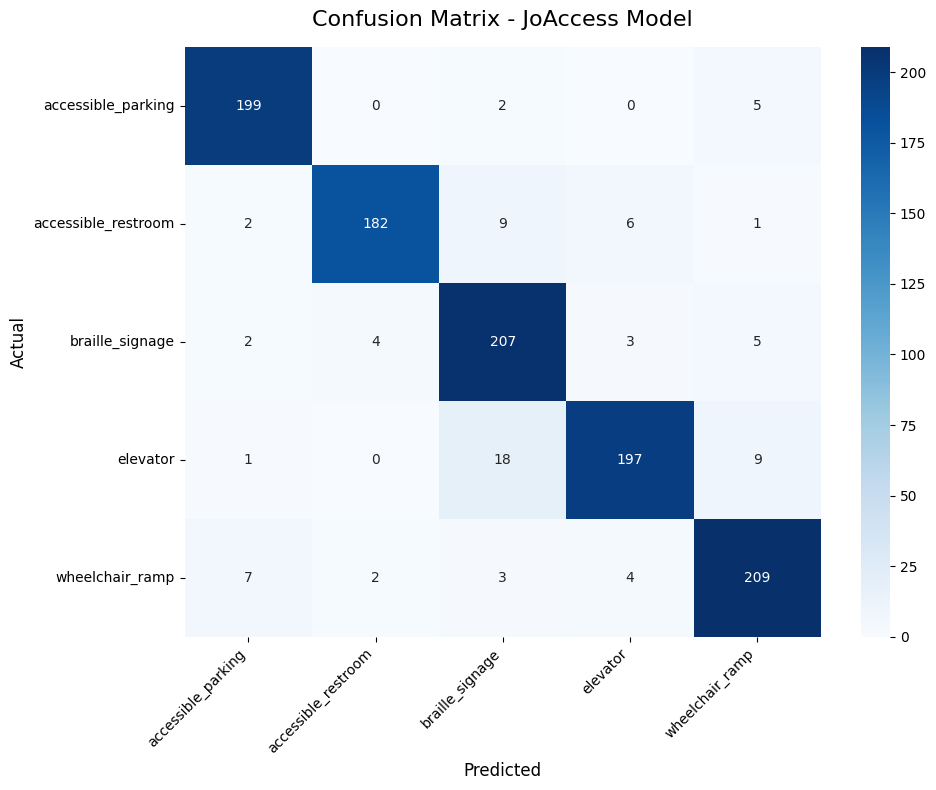

Confusion Matrix saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix - JoAccess Model', fontsize=16, pad=15)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Save to Drive
plt.savefig('/content/drive/MyDrive/joAccess_dataset/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion Matrix saved!')

# Retrain with Early Stopping to Reduce Overfitting

In [11]:
PATIENCE = 5
best_acc = 0.0
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
criterion = nn.CrossEntropyLoss()

print('Retraining with Early Stopping!')
print(f'Patience: {PATIENCE}')
print('=' * 60)

for epoch in range(20):
    start = time.time()

    model.train()
    train_loss, train_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_dataset)
    val_acc   = val_correct   / len(val_dataset)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f'Epoch [{epoch+1:02d}] Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {time.time()-start:.1f}s ✅ Best!')
    else:
        patience_counter += 1
        print(f'Epoch [{epoch+1:02d}] Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {time.time()-start:.1f}s | Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly Stopping at Epoch {epoch+1}!')
        break

    scheduler.step()

print('=' * 60)
print(f'Best Val Accuracy: {best_acc*100:.2f}%')
model.load_state_dict(best_model_wts)
print('Best model loaded!')

Retraining with Early Stopping!
Patience: 5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01] Train: 0.6861 | Val: 0.8030 | Time: 166.2s ✅ Best!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02] Train: 0.7662 | Val: 0.8132 | Time: 158.4s ✅ Best!


...

Epoch [14] Train: 0.8080 | Val: 0.8364 | Time: 149.1s | Patience: 3/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [15] Train: 0.8036 | Val: 0.8253 | Time: 149.1s | Patience: 4/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [16] Train: 0.8114 | Val: 0.8253 | Time: 150.7s | Patience: 5/5

Early Stopping at Epoch 16!
Best Val Accuracy: 83.83%
Best model loaded!


In [12]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

layers = list(model.features.children())
for layer in layers[-10:]:
    for param in layer.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, 5)
)
model = model.to(device)

# Weight Decay + Label Smoothing
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
patience_counter = 0
PATIENCE = 5

print('Training with Weight Decay + Label Smoothing + Early Stopping')
print('=' * 60)

for epoch in range(20):
    start = time.time()

    model.train()
    train_loss, train_correct = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_dataset)
    val_acc   = val_correct   / len(val_dataset)

    if val_acc > best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print(f'Epoch [{epoch+1:02d}] Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {time.time()-start:.1f}s ✅ Best!')
    else:
        patience_counter += 1
        print(f'Epoch [{epoch+1:02d}] Train: {train_acc:.4f} | Val: {val_acc:.4f} | Time: {time.time()-start:.1f}s | Patience: {patience_counter}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly Stopping at Epoch {epoch+1}!')
        break

    scheduler.step()

print('=' * 60)
print(f'Best Val Accuracy: {best_acc*100:.2f}%')
model.load_state_dict(best_model_wts)
print('Best model loaded!')

Training with Weight Decay + Label Smoothing + Early Stopping


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [01] Train: 0.7971 | Val: 0.8838 | Time: 164.9s ✅ Best!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [02] Train: 0.8847 | Val: 0.8941 | Time: 163.2s ✅ Best!


...

Epoch [18] Train: 0.9877 | Val: 0.9442 | Time: 163.5s ✅ Best!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [19] Train: 0.9888 | Val: 0.9414 | Time: 162.1s | Patience: 1/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [20] Train: 0.9881 | Val: 0.9405 | Time: 159.3s | Patience: 2/5
Best Val Accuracy: 94.42%
Best model loaded!
